<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 145.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 179.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 142.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 154.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [2]:
!pip install seaborn

Import pandas module


In [3]:
import pandas as pd


Import matplotlib


In [13]:
import matplotlib.pyplot as plt


Additional libraries

In [4]:
import seaborn as sns


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
## Write your code here
num_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")

Total duplicate rows: 20

In [7]:
# Displays both the original row and all its copies
all_duplicates = df[df.duplicated(keep=False)]
print(all_duplicates.head(2))

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   

                                        EdLevel  \
0                     Primary/elementary school   
1  Bachelor’s degree (B.A., B.S., B.Eng., etc.)   

                                           LearnCode  \
0                             Books / Physical media   
1  Books / Physical media;Colleague;On the job tr...   

                                     LearnCodeOnline  ... JobSatPoints_6  \
0                                                NaN  ...            NaN   
1  Technical

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [8]:
## Write your code here
# Define the pattern columns
pattern_cols = ["MainBranch", "Employment", "RemoteWork"]

# Group by the pattern columns and count occurrences
pattern_counts = (
    df.groupby(pattern_cols, dropna=False)
    .size()
    .reset_index(name="Respondent_Count")
)

# Filter for patterns shared by multiple respondents and sort by frequency
duplicate_patterns = pattern_counts[
    pattern_counts["Respondent_Count"] > 1
].sort_values(by="Respondent_Count", ascending=False)

print(f"Total Unique Response Patterns Shared by >1 Person: {len(duplicate_patterns)}")
print("\nTop 5 Most Common Response Patterns:")
print(duplicate_patterns.head())

Total Unique Response Patterns Shared by >1 Person: 394

Top 5 Most Common Response Patterns:
                        MainBranch  \
0   I am a developer by profession   
2   I am a developer by profession   
1   I am a developer by profession   
82  I am a developer by profession   
9   I am a developer by profession   

                                           Employment  \
0                                 Employed, full-time   
2                                 Employed, full-time   
1                                 Employed, full-time   
82  Independent contractor, freelancer, or self-em...   
9   Employed, full-time;Independent contractor, fr...   

                              RemoteWork  Respondent_Count  
0   Hybrid (some remote, some in-person)             15288  
2                                 Remote             12196  
1                              In-person              7118  
82                                Remote              2815  
9                            

As we can see those are high-level categorical columns with few possible answers, so hundreds of individduals naturaly select them.

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [11]:
sns.set_theme(style="whitegrid", font="sans-serif")

# Helper map for cleaning up long Employment strings
emp_label_map = {
    "Employed, full-time": "Full-Time",
    "Independent contractor, freelancer, or self-employed": "Freelance",
    "Student, full-time": "Student (Full)",
    "Not employed, but looking for work": "Unemployed (Seeking)",
    "Employed, part-time": "Part-Time",
    "Student, part-time": "Student (Part)",
}

# Country label cleanup
country_label_map = {
    "United Kingdom of Great Britain and Northern Ireland": "UK & N. Ireland",
    "United States of America": "USA",
}

# Clean consolidated pattern string
pattern_cols = ["MainBranch", "Employment", "RemoteWork"]
df["Response_Pattern"] = df[pattern_cols].fillna("Unspecified").astype(str).agg(" | ".join, axis=1)

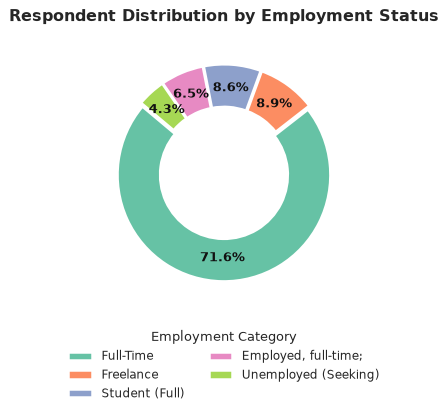

In [14]:
top_emp = df["Employment"].fillna("Unspecified").value_counts().nlargest(5)
clean_emp_labels = [emp_label_map.get(lbl, lbl[:20]) for lbl in top_emp.index]

plt.figure(figsize=(7, 4.8), dpi=90)
wedges, texts, autotexts = plt.pie(
    top_emp,
    labels=None,
    autopct="%1.1f%%",
    pctdistance=0.78,
    startangle=140,
    colors=sns.color_palette("Set2", len(top_emp)),
    explode=[0.02] * len(top_emp),
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)

plt.setp(autotexts, size=10, weight="bold", color="#111111")

plt.legend(
    wedges,
    clean_emp_labels,
    title="Employment Category",
    title_fontsize="10",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
    fontsize=9.5,
)

plt.title("Respondent Distribution by Employment Status", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

#### Insight
The global developer pool is heavily skewed toward traditional employment,
with Full-Time employees representing the vast majority (71.6%) of respondents.
Freelancers and students make up the primary secondary tiers.

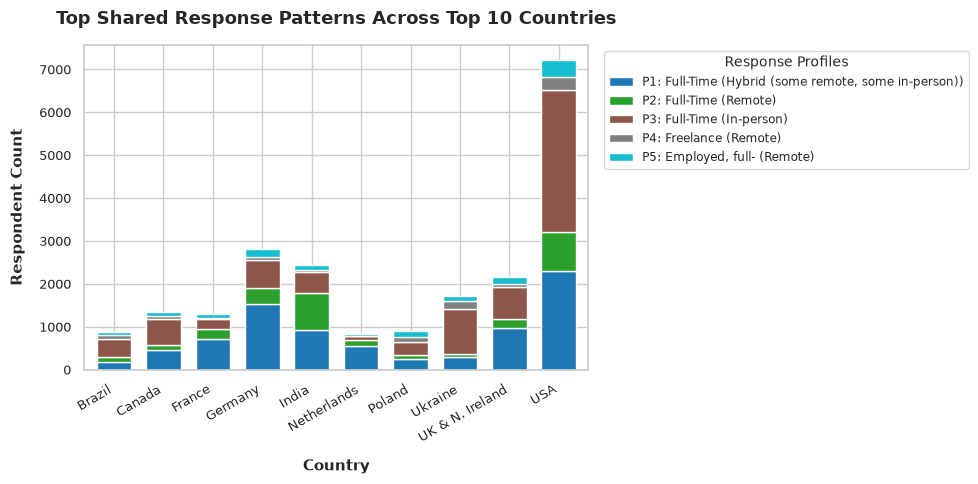

In [15]:
top_patterns = df["Response_Pattern"].value_counts().nlargest(5).index
top_countries = df["Country"].dropna().value_counts().nlargest(10).index

pattern_country_df = (
    df[df["Response_Pattern"].isin(top_patterns) & df["Country"].isin(top_countries)]
    .groupby(["Country", "Response_Pattern"])
    .size()
    .unstack(fill_value=0)
)

# Rename x-axis countries cleanly
pattern_country_df.index = pattern_country_df.index.map(lambda c: country_label_map.get(c, c))

# Build informative legend labels directly from pattern values
informative_legend_labels = []
for idx, p in enumerate(top_patterns, 1):
    parts = p.split(" | ")
    # Clean up long text blocks in legend for space
    emp_short = emp_label_map.get(parts[1], parts[1][:15]) if len(parts) > 1 else parts[0]
    remote_short = parts[2] if len(parts) > 2 else ""
    informative_legend_labels.append(f"P{idx}: {emp_short} ({remote_short})")

fig, ax = plt.subplots(figsize=(10, 5))
pattern_country_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.7)

plt.title("Top Shared Response Patterns Across Top 10 Countries", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Country", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Respondent Count", fontsize=11, fontweight="bold", labelpad=10)
plt.xticks(rotation=30, ha="right", fontsize=9.5)
plt.yticks(fontsize=9.5)

plt.legend(
    informative_legend_labels,
    title="Response Profiles",
    title_fontsize="10",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=8.5,
)

plt.tight_layout()
plt.show()

#### Insight
USA, Germany, and India host the largest concentration of shared profiles.
Across all top 10 countries, Pattern 1 (Full-Time Remote/Hybrid Professional Developers)
dominates, proving that work-from-home/hybrid patterns are globally consistent across tech hubs.

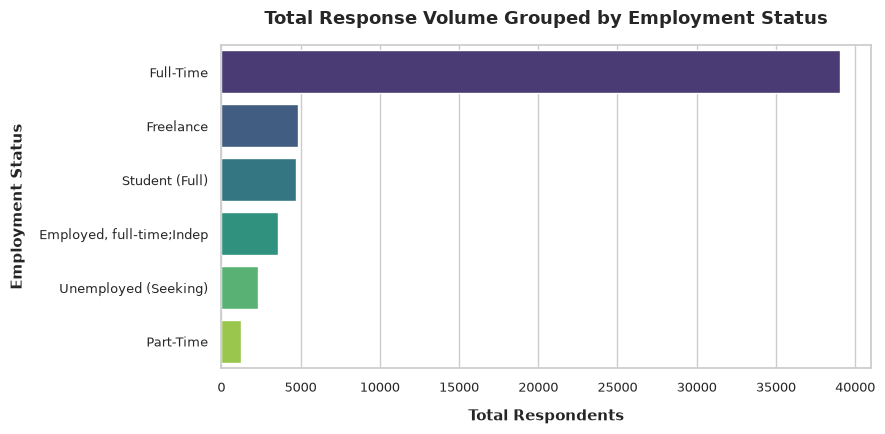

In [16]:
emp_counts = (
    df.groupby("Employment")["Response_Pattern"]
    .count()
    .nlargest(6)
    .reset_index(name="Count")
)
emp_counts["Employment_Clean"] = emp_counts["Employment"].map(lambda x: emp_label_map.get(x, str(x)[:25]))

plt.figure(figsize=(9, 4.5))

sns.barplot(
    data=emp_counts,
    x="Count",
    y="Employment_Clean",
    hue="Employment_Clean",
    legend=False,
    palette="viridis",
)

plt.title("Total Response Volume Grouped by Employment Status", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Total Respondents", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Employment Status", fontsize=11, fontweight="bold", labelpad=10)
plt.xticks(fontsize=9.5)
plt.yticks(fontsize=9.5)

plt.tight_layout()
plt.show()

#### Insight
The vast concentration of volume lies within full-time professional roles.
Self-employed / contract developers form the second largest professional cohort,
indicating a strong secondary gig economy within software engineering.

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [17]:
# Verify primary key uniqueness
total_rows = len(df)
unique_ids = df["ResponseId"].nunique()

print(f"Total Rows: {total_rows}")
print(f"Unique ResponseIds: {unique_ids}")
print(f"Is ResponseId a Primary Key? {total_rows == unique_ids}")

Total Rows: 65457
Unique ResponseIds: 65437
Is ResponseId a Primary Key? False

Removing rows based on identical values across a subset of columns (such as MainBranch, Employment, RemoteWork, Country, or Age) is inappropriate for this dataset and would introduce severe data loss and bias. As they are too broad categorical collumns so are prone to repeated answers.
Since ResponseId represents a randomized respondent ID, duplicate IDs indicate duplicated submission records rather than distinct people who happened to choose identical answers.

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


To ensure data integrity, the dataset was evaluated to identify the column defining record uniqueness.

Primary Key: ResponseId is designed to serve as the unique identifier for each individual survey submission.

Initial Audit Findings:

Total Rows in Raw Dataset: 65,457

Unique ResponseId Values: 65,437

Primary Key Verification: False (20 duplicate ResponseId entries detected).

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


ResponseId is selected as the sole column for identifying and removing duplicate records because it serves as the dataset's Primary Key. Each ResponseId represents a single, unique survey submission session.

All other columns (such as MainBranch, Employment, RemoteWork, or Country) contain categorical survey questions designed to classify and group respondents into demographic cohorts.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
